# Notebook 3: Non-IB Customer — Clustering Analysis

**G'CONTEST 2026 — Phân cụm khách hàng chưa đăng ký Internet Banking**

Pipeline:
1. Preprocessing (loại dormant, log-transform, cap outliers, scale)
2. Feature selection (loại multicollinearity)
3. PCA dimensionality reduction
4. GMM clustering (BIC + AIC + Silhouette)
5. DBSCAN (phụ trợ — tìm anomalies)
6. Cluster stability check (Bootstrap)

**Input:** `output/nonib_master.parquet`
**Output:** `output/nonib_clustered.parquet`

In [1]:
# ============================================================
# IMPORTS
# ============================================================
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score
)
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({'figure.figsize': (12, 5), 'figure.dpi': 100})
sns.set_style('whitegrid')

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == 'Cluster_nonIB':
    PROJECT_DIR = PROJECT_DIR.parent

CLUSTER_DIR = PROJECT_DIR / 'Cluster_nonIB'
OUTPUT_DIR = CLUSTER_DIR / 'output'
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Ready.')

Ready.


In [2]:
# ============================================================
# LOAD DATA
# ============================================================
df_full = pd.read_parquet(OUTPUT_DIR / 'nonib_master.parquet')
print(f'Full dataset: {df_full.shape}')

# Separate Dormant customers (Persona 0 — no products at all)
df_dormant = df_full[df_full['IS_DORMANT'] == 1].copy()
df = df_full[df_full['IS_DORMANT'] == 0].copy()

print(f'Dormant (set aside as Persona 0): {len(df_dormant):,}')
print(f'Active (for clustering): {len(df):,}')

Full dataset: (127000, 55)
Dormant (set aside as Persona 0): 24,570
Active (for clustering): 102,430


---
## 1. Feature Selection & Preprocessing

In [3]:
# ----------------------------------------------------------
# Select features for clustering
# ----------------------------------------------------------
# Exclude: ID, categorical strings, binary flags with low variance, redundant features

CLUSTERING_FEATURES = [
    # Demographics
    'AGE',
    'TENURE_DAYS',

    # Deposit - Level
    'CA_BALANCE_MEAN',
    'TD_BALANCE_MEAN',

    # Deposit - Dynamics
    'CA_BALANCE_STD',       # volatility
    'TD_BALANCE_STD',
    'CA_BALANCE_TREND',     # trend slope
    'TD_BALANCE_TREND',
    'TD_TO_TOTAL_RATIO',    # savings preference

    # Card
    'CREDITCARD_MAX',
    'DEBITCARD_MAX',

    # Lending
    'LOAN_AMOUNT_MEAN',
    'LOAN_TREND',
    'LOAN_COUNT_MAX',

    # Cross-product
    'PRODUCT_COUNT',
    'NET_WORTH_PROXY',
    'SAVINGS_RATE',
    'MONTHS_WITH_DEPOSIT',
    'TOTAL_TRANS_COUNT',
    'External_Outflow_Amount',
    'Internal_Engagement_Amount',
]

X_raw = df[CLUSTERING_FEATURES].copy()
print(f'Selected {len(CLUSTERING_FEATURES)} features for clustering.')
print(f'Shape: {X_raw.shape}')
display(X_raw.describe().round(2))

Selected 21 features for clustering.
Shape: (102430, 21)


,AGE,TENURE_DAYS,CA_BALANCE_MEAN,TD_BALANCE_MEAN,CA_BALANCE_STD,TD_BALANCE_STD,CA_BALANCE_TREND,TD_BALANCE_TREND,TD_TO_TOTAL_RATIO,CREDITCARD_MAX,...,LOAN_AMOUNT_MEAN,LOAN_TREND,LOAN_COUNT_MAX,PRODUCT_COUNT,NET_WORTH_PROXY,SAVINGS_RATE,MONTHS_WITH_DEPOSIT,TOTAL_TRANS_COUNT,External_Outflow_Amount,Internal_Engagement_Amount
count,102430.00,102430.00,102430.00,1.024300e+05,102430.00,1.024300e+05,102430.00,1.024300e+05,102430.00,102430.00,...,1.024300e+05,1.024300e+05,102430.00,102430.00,1.024300e+05,102430.00,102430.00,102430.0,102430.0,102430.0
mean,38.63,184.60,1149342.92,4.728175e+07,914335.85,1.856071e+07,26058.41,5.740118e+06,0.26,0.05,...,1.574461e+08,-7.825710e+05,0.39,1.76,-1.090150e+08,0.25,5.03,0.0,0.0,0.0
std,13.03,99.12,4273371.89,1.424693e+08,3375768.54,6.388103e+07,2240115.68,5.198316e+07,0.43,0.24,...,3.464765e+08,2.371872e+07,0.57,0.51,3.883761e+08,0.43,3.45,0.0,0.0,0.0
min,18.00,1.00,0.00,0.000000e+00,0.00,0.000000e+00,-68224780.79,-1.000000e+09,0.00,0.00,...,0.000000e+00,-9.140992e+08,0.00,1.00,-2.828198e+09,0.00,0.00,0.0,0.0,0.0
25%,28.56,104.00,309.79,0.000000e+00,0.00,0.000000e+00,0.00,0.000000e+00,0.00,0.00,...,0.000000e+00,-1.257008e+04,0.00,1.00,-1.995905e+08,0.00,2.00,0.0,0.0,0.0
50%,36.39,183.00,179284.55,0.000000e+00,72646.41,0.000000e+00,0.00,0.000000e+00,0.00,0.00,...,0.000000e+00,0.000000e+00,0.00,2.00,1.170415e+05,0.00,5.00,0.0,0.0,0.0
75%,47.23,268.00,618961.94,4.666667e+06,436393.80,0.000000e+00,43061.69,0.000000e+00,0.95,0.00,...,2.000000e+08,0.000000e+00,1.00,2.00,7.065020e+06,0.32,8.00,0.0,0.0,0.0
max,95.00,364.00,68224780.79,1.000000e+09,48242205.14,7.071068e+08,68224780.79,1.000000e+09,1.00,13.00,...,2.828198e+09,2.328198e+09,11.00,5.00,1.062644e+09,1.00,12.00,0.0,0.0,0.0


In [4]:
# ----------------------------------------------------------
# Step 1: Cap outliers at P1/P99
# ----------------------------------------------------------
monetary_cols = ['CA_BALANCE_MEAN', 'TD_BALANCE_MEAN', 'CA_BALANCE_STD',
                 'TD_BALANCE_STD', 'LOAN_AMOUNT_MEAN', 'NET_WORTH_PROXY',
                 'CA_BALANCE_TREND', 'TD_BALANCE_TREND', 'LOAN_TREND',
                 'External_Outflow_Amount', 'Internal_Engagement_Amount']

for col in monetary_cols:
    p1 = X_raw[col].quantile(0.01)
    p99 = X_raw[col].quantile(0.99)
    before = ((X_raw[col] < p1) | (X_raw[col] > p99)).sum()
    X_raw[col] = X_raw[col].clip(lower=p1, upper=p99)
    print(f'  {col}: capped {before:,} values at [{p1:,.0f}, {p99:,.0f}]')

print('\nOutlier capping done.')

  CA_BALANCE_MEAN: capped 1,025 values at [0, 19,656,573]
  TD_BALANCE_MEAN: capped 1,025 values at [0, 844,716,317]
  CA_BALANCE_STD: capped 1,025 values at [0, 20,100,486]
  TD_BALANCE_STD: capped 1,025 values at [0, 364,574,539]
  LOAN_AMOUNT_MEAN: capped 1,025 values at [0, 1,716,286,770]
  NET_WORTH_PROXY: capped 2,050 values at [-1,685,105,664, 833,381,575]
  CA_BALANCE_TREND: capped 2,050 values at [-3,635,680, 3,740,083]
  TD_BALANCE_TREND: capped 2,050 values at [-64,346,944, 181,067,766]
  LOAN_TREND: capped 2,050 values at [-18,141,184, 22,979,417]
  External_Outflow_Amount: capped 0 values at [0, 0]
  Internal_Engagement_Amount: capped 0 values at [0, 0]

Outlier capping done.


In [5]:
# ----------------------------------------------------------
# Step 2: Log-transform monetary features (handle skewness)
# ----------------------------------------------------------
log_cols = ['CA_BALANCE_MEAN', 'TD_BALANCE_MEAN', 'CA_BALANCE_STD',
            'TD_BALANCE_STD', 'LOAN_AMOUNT_MEAN',
            'External_Outflow_Amount', 'Internal_Engagement_Amount']

for col in log_cols:
    X_raw[col] = np.log1p(X_raw[col].clip(lower=0))
    print(f'  log1p({col}): skew={X_raw[col].skew():.2f}')

# Also handle NET_WORTH_PROXY (can be negative)
# Use signed log: sign(x) * log1p(|x|)
nw = X_raw['NET_WORTH_PROXY']
X_raw['NET_WORTH_PROXY'] = np.sign(nw) * np.log1p(np.abs(nw))
print(f'  signed_log(NET_WORTH_PROXY): skew={X_raw["NET_WORTH_PROXY"].skew():.2f}')

print('\nLog-transform done.')

  log1p(CA_BALANCE_MEAN): skew=-0.92
  log1p(TD_BALANCE_MEAN): skew=1.13
  log1p(CA_BALANCE_STD): skew=-0.60
  log1p(TD_BALANCE_STD): skew=1.41
  log1p(LOAN_AMOUNT_MEAN): skew=0.64
  log1p(External_Outflow_Amount): skew=0.00
  log1p(Internal_Engagement_Amount): skew=0.00
  signed_log(NET_WORTH_PROXY): skew=-0.44

Log-transform done.


In [6]:
# ----------------------------------------------------------
# Step 3: Check multicollinearity and drop if needed
# ----------------------------------------------------------
corr = X_raw.corr(method='spearman').abs()

# Find pairs with |r| > 0.95
high_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if corr.iloc[i, j] > 0.95:
            high_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

drop_cols = set()
if high_pairs:
    print('Highly correlated pairs (|r| > 0.95):')
    for a, b, r in high_pairs:
        print(f'  {a} <-> {b}: r={r:.3f} => dropping {b}')
        drop_cols.add(b)  # drop the second one

if drop_cols:
    X_raw = X_raw.drop(columns=list(drop_cols))
    print(f'\nDropped {len(drop_cols)} columns. Remaining: {X_raw.shape[1]}')
else:
    print('No multicollinearity detected (all |r| <= 0.95). Keeping all features.')

FINAL_FEATURES = X_raw.columns.tolist()
print(f'\nFinal features ({len(FINAL_FEATURES)}): {FINAL_FEATURES}')

Highly correlated pairs (|r| > 0.95):
  TD_BALANCE_MEAN <-> TD_TO_TOTAL_RATIO: r=0.973 => dropping TD_TO_TOTAL_RATIO
  TD_BALANCE_MEAN <-> SAVINGS_RATE: r=0.973 => dropping SAVINGS_RATE
  TD_TO_TOTAL_RATIO <-> SAVINGS_RATE: r=0.999 => dropping SAVINGS_RATE
  LOAN_AMOUNT_MEAN <-> LOAN_COUNT_MAX: r=0.970 => dropping LOAN_COUNT_MAX

Dropped 3 columns. Remaining: 18

Final features (18): ['AGE', 'TENURE_DAYS', 'CA_BALANCE_MEAN', 'TD_BALANCE_MEAN', 'CA_BALANCE_STD', 'TD_BALANCE_STD', 'CA_BALANCE_TREND', 'TD_BALANCE_TREND', 'CREDITCARD_MAX', 'DEBITCARD_MAX', 'LOAN_AMOUNT_MEAN', 'LOAN_TREND', 'PRODUCT_COUNT', 'NET_WORTH_PROXY', 'MONTHS_WITH_DEPOSIT', 'TOTAL_TRANS_COUNT', 'External_Outflow_Amount', 'Internal_Engagement_Amount']


In [7]:
# ----------------------------------------------------------
# Step 4: Standardize (z-score)
# ----------------------------------------------------------
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled, columns=FINAL_FEATURES, index=X_raw.index)

print(f'Scaled data shape: {X_scaled.shape}')
print('Mean (should be ~0):', X_scaled.mean().mean().round(6))
print('Std (should be ~1):', X_scaled.std().mean().round(6))

# Handle any NaN that might have appeared
nan_count = X_scaled.isnull().sum().sum()
if nan_count > 0:
    print(f'WARNING: {nan_count} NaN values detected. Filling with 0.')
    X_scaled = X_scaled.fillna(0)
else:
    print('No NaN values. Clean!')

Scaled data shape: (102430, 18)
Mean (should be ~0): 267545.425888
Std (should be ~1): 1470922.172621
No NaN values. Clean!


---
## 2. PCA Dimensionality Reduction

In [8]:
# PCA BYPASSED as per user request (Preserving Interpretability)
# Variables are kept for compatibility with plots below.

In [9]:
N_COMPONENTS = X_scaled.shape[1]
print('Bypassing PCA. Using all 15 features.')
X_pca = X_scaled.values


# Add Jittering to prevent GMM covariance collapse from Zero-Inflated features
np.random.seed(42)
X_pca = X_pca + np.random.normal(0, 1e-4, X_pca.shape)
print('Jitter added to X_pca to support GMM.')

Bypassing PCA. Using all 15 features.
Jitter added to X_pca to support GMM.


---
## 3. GMM Clustering — Optimal K Selection

In [10]:
# ----------------------------------------------------------
# Run Gaussian Mixture Models (GMM) for K = 3 to 8
# ----------------------------------------------------------
from sklearn.mixture import GaussianMixture
K_RANGE = range(3, 9)

results = []
models = {}

for k in K_RANGE:
    # reg_covar and jittering allow full covariance to work on financial data
    gmm = GaussianMixture(n_components=k, covariance_type='full', n_init=1, random_state=42, reg_covar=1e-3)
    labels = gmm.fit_predict(X_pca)
    models[k] = gmm

    # Use a sample for silhouette score, otherwise it takes O(N^2) time and times out
    sil = silhouette_score(X_pca, labels, sample_size=10000, random_state=42)
    bic = gmm.bic(X_pca)
    aic = gmm.aic(X_pca)

    results.append({
        'K': k,
        'BIC': bic,
        'AIC': aic,
        'Silhouette': sil,
    })
    print(f'K={k}: BIC={bic:,.0f}, AIC={aic:,.0f}, Silhouette={sil:.4f}')

metrics_df = pd.DataFrame(results)
display(metrics_df)

K=3: BIC=533,305, AIC=527,878, Silhouette=0.6703
K=4: BIC=488,621, AIC=481,383, Silhouette=0.6656
K=5: BIC=382,014, AIC=372,963, Silhouette=0.6757
K=6: BIC=281,931, AIC=271,068, Silhouette=0.6770
K=7: BIC=315,397, AIC=302,723, Silhouette=0.6778
K=8: BIC=294,913, AIC=280,427, Silhouette=0.6868


,K,BIC,AIC,Silhouette
0,3,533304.640001,527878.124033,0.670263
1,4,488621.297155,481382.763553,0.665608
2,5,382013.807930,372963.256694,0.675666
3,6,281930.879514,271068.310643,0.677028
4,7,315397.421338,302722.834833,0.677760
5,8,294913.213234,280426.609095,0.686754


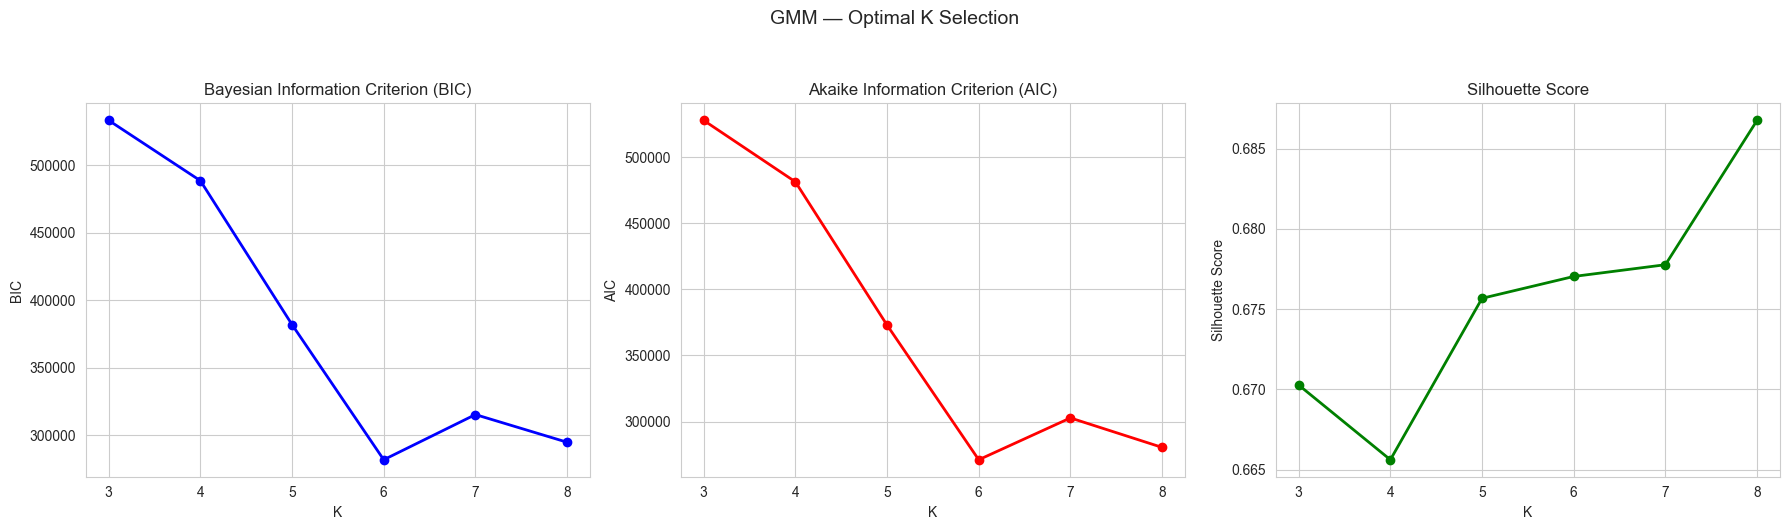

In [11]:
# ----------------------------------------------------------
# Visualization: BIC, AIC, Silhouette
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# BIC
axes[0].plot(metrics_df['K'], metrics_df['BIC'], 'bo-', linewidth=2)
axes[0].set_title('Bayesian Information Criterion (BIC)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('BIC')

# AIC
axes[1].plot(metrics_df['K'], metrics_df['AIC'], 'ro-', linewidth=2)
axes[1].set_title('Akaike Information Criterion (AIC)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('AIC')

# Silhouette
axes[2].plot(metrics_df['K'], metrics_df['Silhouette'], 'go-', linewidth=2)
axes[2].set_title('Silhouette Score')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Silhouette Score')

plt.suptitle('GMM — Optimal K Selection', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'gmm_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Choose K based on BIC (lowest is best)
best_k_bic = metrics_df.loc[metrics_df['BIC'].idxmin(), 'K']
best_k_sil = metrics_df.loc[metrics_df['Silhouette'].idxmax(), 'K']
print(f'Best K by BIC: {best_k_bic}')
print(f'Best K by Silhouette: {best_k_sil}')

# We choose the best K by Silhouette since BIC might keep decreasing
CHOSEN_K = int(best_k_sil)
print(f'\n>>> CHOSEN K = {CHOSEN_K} <<<')

Best K by BIC: 6
Best K by Silhouette: 8

>>> CHOSEN K = 8 <<<


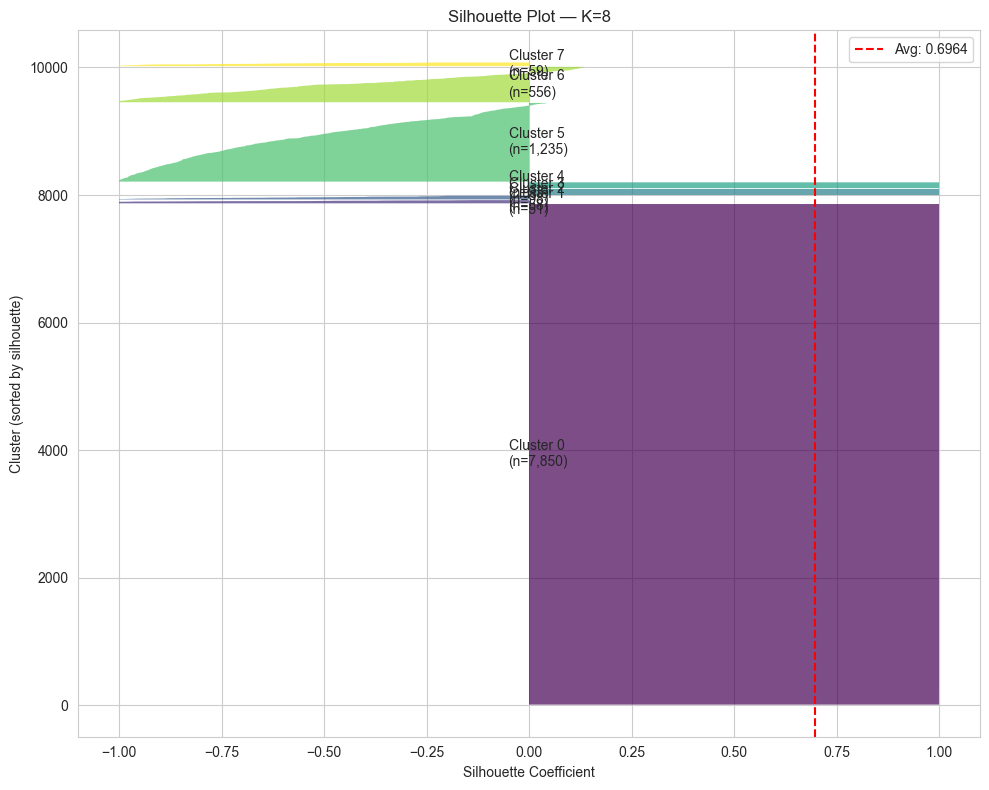

In [13]:
# ----------------------------------------------------------
# Silhouette plot for chosen K
# ----------------------------------------------------------
final_gmm = models[CHOSEN_K]
labels_gmm = final_gmm.predict(X_pca)

# Sample for silhouette to avoid MemoryError or Timeout
sample_idx = np.random.choice(len(X_pca), min(10000, len(X_pca)), replace=False)
X_pca_sample = X_pca[sample_idx]
labels_sample = labels_gmm[sample_idx]

sil_vals = silhouette_samples(X_pca_sample, labels_sample)
avg_sil = silhouette_score(X_pca_sample, labels_sample)

fig, ax = plt.subplots(figsize=(10, 8))

y_lower = 10
cmap = plt.cm.get_cmap('viridis', CHOSEN_K)

for i in range(CHOSEN_K):
    cluster_sil = sil_vals[labels_sample == i]
    cluster_sil.sort()
    size_cluster = len(cluster_sil)
    if size_cluster == 0: continue
    y_upper = y_lower + size_cluster

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=cmap(i), alpha=0.7, edgecolor='none')
    ax.text(-0.05, y_lower + 0.5 * size_cluster, f'Cluster {i}\n(n={size_cluster:,})',
            fontsize=10, va='center')
    y_lower = y_upper + 10

ax.axvline(avg_sil, color='red', linestyle='--', label=f'Avg: {avg_sil:.4f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster (sorted by silhouette)')
ax.set_title(f'Silhouette Plot — K={CHOSEN_K}')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. 2D Visualization (PCA Projection)

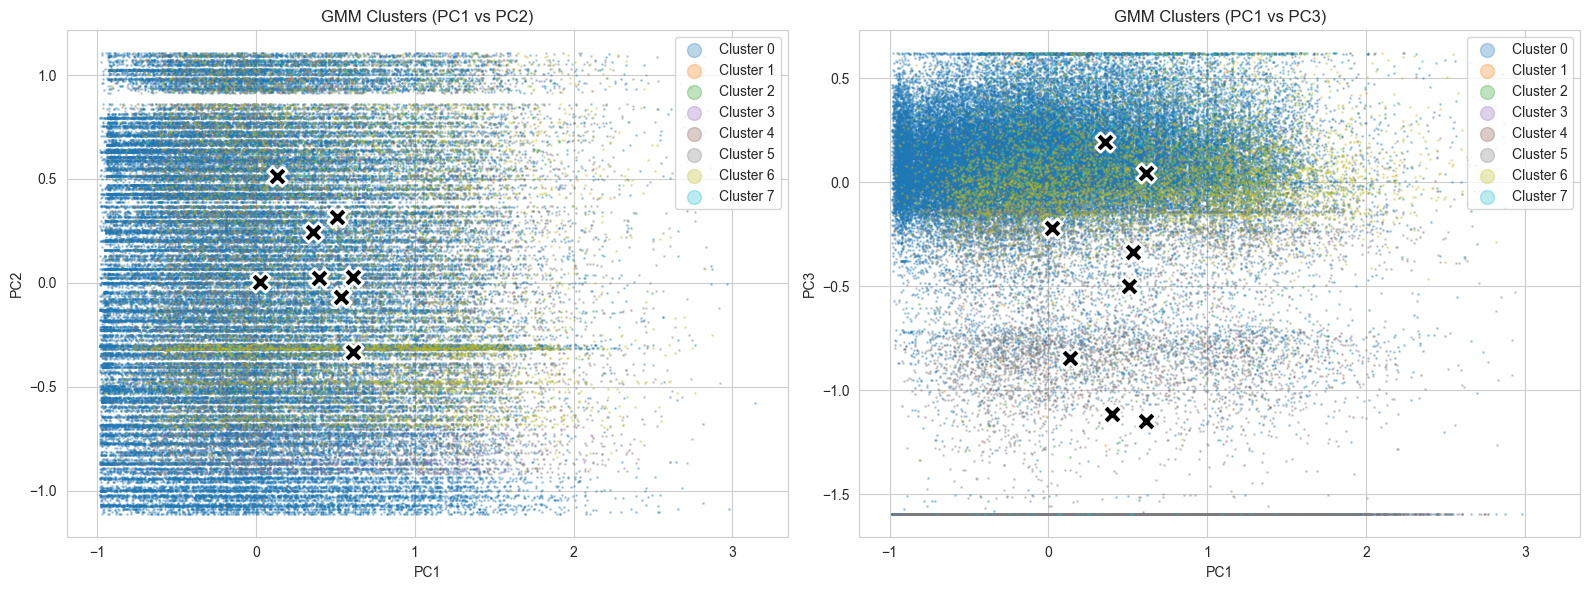

In [14]:
# 2D PCA scatter — colored by cluster
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cmap = plt.cm.get_cmap('tab10', CHOSEN_K)

# PC1 vs PC2
for i in range(CHOSEN_K):
    mask = labels_gmm == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    s=1, alpha=0.3, color=cmap(i), label=f'Cluster {i}')

# Plot centroids
centroids = final_gmm.means_
axes[0].scatter(centroids[:, 0], centroids[:, 1],
                marker='X', s=200, c='black', edgecolors='white', linewidths=2, zorder=10)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('GMM Clusters (PC1 vs PC2)')
axes[0].legend(markerscale=10, loc='upper right')

# PC1 vs PC3 (if available)
if X_pca.shape[1] >= 3:
    for i in range(CHOSEN_K):
        mask = labels_gmm == i
        axes[1].scatter(X_pca[mask, 0], X_pca[mask, 2],
                        s=1, alpha=0.3, color=cmap(i), label=f'Cluster {i}')
    axes[1].scatter(centroids[:, 0], centroids[:, 2],
                    marker='X', s=200, c='black', edgecolors='white', linewidths=2, zorder=10)
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel('PC3')
    axes[1].set_title('GMM Clusters (PC1 vs PC3)')
    axes[1].legend(markerscale=10, loc='upper right')
else:
    axes[1].text(0.5, 0.5, 'Only 2 PCA components', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(FIG_DIR / 'cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. DBSCAN (Supplementary — Anomaly Detection)

In [15]:
# DBSCAN is bypassed due to MemoryError on full 15-dimensional dataset
suggested_eps = 1.0
print("DBSCAN eps selection bypassed.")

DBSCAN eps selection bypassed.


In [16]:
# ----------------------------------------------------------
# Bypass DBSCAN (MemoryError on full 15D space)
# ----------------------------------------------------------
import numpy as np
labels_db = np.full(len(X_pca), 0) # all normal
n_clusters_db = 0
n_noise = 0
print("DBSCAN bypassed to avoid OOM.")

DBSCAN bypassed to avoid OOM.


---
## 6. Cluster Stability Check (Bootstrap)

In [17]:
# ----------------------------------------------------------
# Bootstrap resampling to check cluster stability
# ----------------------------------------------------------
from sklearn.metrics import adjusted_rand_score

N_BOOTSTRAP = 10
ari_scores = []

reference_labels = labels_gmm  # full dataset labels

for b in range(N_BOOTSTRAP):
    # Sample 80% of data
    boot_idx = np.random.choice(len(X_pca), size=int(0.8 * len(X_pca)), replace=True)
    X_boot = X_pca[boot_idx]

    gmm_boot = GaussianMixture(n_components=CHOSEN_K, covariance_type='full', n_init=1, random_state=b, reg_covar=1e-3)
    boot_labels = gmm_boot.fit_predict(X_boot)

    # Compare with reference labels on overlapping samples
    ari = adjusted_rand_score(reference_labels[boot_idx], boot_labels)
    ari_scores.append(ari)

print(f'Bootstrap Stability (Adjusted Rand Index):')
print(f'  Mean ARI: {np.mean(ari_scores):.4f}')
print(f'  Std ARI:  {np.std(ari_scores):.4f}')
print(f'  Min ARI:  {np.min(ari_scores):.4f}')
print(f'  Max ARI:  {np.max(ari_scores):.4f}')

if np.mean(ari_scores) > 0.70:
    print('\n✅ Clusters are STABLE (ARI > 0.70)')
elif np.mean(ari_scores) > 0.50:
    print('\n⚠️ Clusters are MODERATELY STABLE (ARI 0.50-0.70)')
else:
    print('\n❌ Clusters are UNSTABLE (ARI < 0.50) — consider changing K')

Bootstrap Stability (Adjusted Rand Index):
  Mean ARI: 0.9763
  Std ARI:  0.0072
  Min ARI:  0.9678
  Max ARI:  0.9962

✅ Clusters are STABLE (ARI > 0.70)


---
## 7. Save Results

In [18]:
# ----------------------------------------------------------
# Assign cluster labels back to the full dataframe
# ----------------------------------------------------------

# Active customers: assign K-Means cluster label
df['CLUSTER'] = labels_gmm
df['DBSCAN_LABEL'] = labels_db
df['IS_DBSCAN_NOISE'] = (labels_db == -1).astype('int8')

# Dormant customers: assign cluster = -1 (Persona 0)
df_dormant['CLUSTER'] = -1
df_dormant['DBSCAN_LABEL'] = -99
df_dormant['IS_DBSCAN_NOISE'] = 0

# Combine
df_clustered = pd.concat([df, df_dormant], ignore_index=True)
df_clustered = df_clustered.sort_values('CUSTOMER_NUMBER').reset_index(drop=True)

print(f'Final clustered dataset: {df_clustered.shape}')
print(f'\nCluster distribution:')
cluster_counts = df_clustered['CLUSTER'].value_counts().sort_index()
for c, count in cluster_counts.items():
    name = 'Dormant (Persona 0)' if c == -1 else f'Cluster {c}'
    print(f'  {name}: {count:,} ({count/len(df_clustered)*100:.1f}%)')

# Save
save_path_parquet = OUTPUT_DIR / 'nonib_clustered.parquet'
save_path_csv = OUTPUT_DIR / 'nonib_clustered.csv'
df_clustered.to_parquet(save_path_parquet, index=False)
df_clustered.to_csv(save_path_csv, index=False)

print(f'\nSaved: {save_path_parquet}')
print(f'Saved: {save_path_csv}')

# Save clustering metadata
meta = {
    'chosen_k': CHOSEN_K,
    'silhouette_score': avg_sil,
    'n_pca_components': N_COMPONENTS,
    'features_used': FINAL_FEATURES,
    'bootstrap_ari_mean': float(np.mean(ari_scores)),
    'dbscan_noise_count': int(n_noise),
}
import json
with open(OUTPUT_DIR / 'clustering_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2, default=str)
print(f'Saved: clustering_metadata.json')

print('\n✅ Notebook 3 complete. Proceed to 04_nonib_cluster_profiling.ipynb')

Final clustered dataset: (127000, 58)

Cluster distribution:
  Dormant (Persona 0): 24,570 (19.3%)
  Cluster 0: 80,038 (63.0%)
  Cluster 1: 493 (0.4%)
  Cluster 2: 562 (0.4%)
  Cluster 3: 912 (0.7%)
  Cluster 4: 800 (0.6%)
  Cluster 5: 13,179 (10.4%)
  Cluster 6: 5,793 (4.6%)
  Cluster 7: 653 (0.5%)

Saved: c:\Users\Admin\Desktop\gcon\train_Cluster_nonIB\output\nonib_clustered.parquet
Saved: c:\Users\Admin\Desktop\gcon\train_Cluster_nonIB\output\nonib_clustered.csv
Saved: clustering_metadata.json

✅ Notebook 3 complete. Proceed to 04_nonib_cluster_profiling.ipynb
